In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/food-delivery-route-efficiency-dataset/Food_Delivery_Route_Efficiency_Dataset.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
import plotly.express as px
from plotly.offline import init_notebook_mode, iplot  
init_notebook_mode(connected=True)

In [4]:
df = pd.read_csv("/kaggle/input/food-delivery-route-efficiency-dataset/Food_Delivery_Route_Efficiency_Dataset.csv")
df

,order_id,distance_km,delivery_time_min,traffic_level,route_length_km,delivery_mode,weather,order_time,restaurant_zone,customer_zone
0,1,7.97,63.8,High,9.75,Bicycle,Clear,2025-01-01 15:29,South,North
1,2,0.90,7.6,High,1.28,Car,Cloudy,2025-01-03 00:47,West,North
2,3,11.12,78.0,Medium,16.65,Bike,Rainy,2025-01-04 17:32,South,Central
3,4,4.90,24.8,Low,5.25,Scooter,Rainy,2025-01-01 14:12,Central,Central
4,5,10.04,56.0,High,11.34,Car,Rainy,2025-01-02 16:50,West,North
...,...,...,...,...,...,...,...,...,...,...
195,196,9.02,38.4,Low,9.57,Bike,Cloudy,2025-01-03 09:22,Central,South
196,197,6.73,59.2,Low,10.04,Bike,Cloudy,2025-01-03 03:32,South,South
197,198,6.98,51.4,High,7.83,Scooter,Cloudy,2025-01-01 08:03,Central,West
198,199,3.80,29.2,Medium,5.34,Bicycle,Rainy,2025-01-04 07:34,South,North


In [5]:
df.info

<bound method DataFrame.info of      order_id  distance_km  delivery_time_min traffic_level  route_length_km  \
0           1         7.97               63.8          High             9.75   
1           2         0.90                7.6          High             1.28   
2           3        11.12               78.0        Medium            16.65   
3           4         4.90               24.8           Low             5.25   
4           5        10.04               56.0          High            11.34   
..        ...          ...                ...           ...              ...   
195       196         9.02               38.4           Low             9.57   
196       197         6.73               59.2           Low            10.04   
197       198         6.98               51.4          High             7.83   
198       199         3.80               29.2        Medium             5.34   
199       200         6.55               40.8        Medium             7.72   

    del

In [6]:
df.head()

,order_id,distance_km,delivery_time_min,traffic_level,route_length_km,delivery_mode,weather,order_time,restaurant_zone,customer_zone
0,1,7.97,63.8,High,9.75,Bicycle,Clear,2025-01-01 15:29,South,North
1,2,0.90,7.6,High,1.28,Car,Cloudy,2025-01-03 00:47,West,North
2,3,11.12,78.0,Medium,16.65,Bike,Rainy,2025-01-04 17:32,South,Central
3,4,4.90,24.8,Low,5.25,Scooter,Rainy,2025-01-01 14:12,Central,Central
4,5,10.04,56.0,High,11.34,Car,Rainy,2025-01-02 16:50,West,North


In [7]:
df.tail ()

,order_id,distance_km,delivery_time_min,traffic_level,route_length_km,delivery_mode,weather,order_time,restaurant_zone,customer_zone
195,196,9.02,38.4,Low,9.57,Bike,Cloudy,2025-01-03 09:22,Central,South
196,197,6.73,59.2,Low,10.04,Bike,Cloudy,2025-01-03 03:32,South,South
197,198,6.98,51.4,High,7.83,Scooter,Cloudy,2025-01-01 08:03,Central,West
198,199,3.80,29.2,Medium,5.34,Bicycle,Rainy,2025-01-04 07:34,South,North
199,200,6.55,40.8,Medium,7.72,Car,Windy,2025-01-04 15:12,South,North


In [8]:
df.describe() 

,order_id,distance_km,delivery_time_min,route_length_km
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,6.624750,44.744500,8.155850
std,57.879185,3.371918,25.083925,4.303207
min,1.000000,0.530000,2.400000,0.580000
25%,50.750000,3.687500,23.725000,4.420000
50%,100.500000,6.845000,44.650000,8.520000
75%,150.250000,9.797500,63.900000,11.800000
max,200.000000,12.000000,108.800000,17.290000


In [9]:
df.columns

Index(['order_id', 'distance_km', 'delivery_time_min', 'traffic_level',
       'route_length_km', 'delivery_mode', 'weather', 'order_time',
       'restaurant_zone', 'customer_zone'],
      dtype='object')

In [10]:
df.isnull().sum()

order_id             0
distance_km          0
delivery_time_min    0
traffic_level        0
route_length_km      0
delivery_mode        0
weather              0
order_time           0
restaurant_zone      0
customer_zone        0
dtype: int64

In [11]:
df['order_time'] = pd.to_datetime(df['order_time'])
df['hour'] = df['order_time'].dt.hour
df['weekday'] = df['order_time'].dt.day_name() 

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



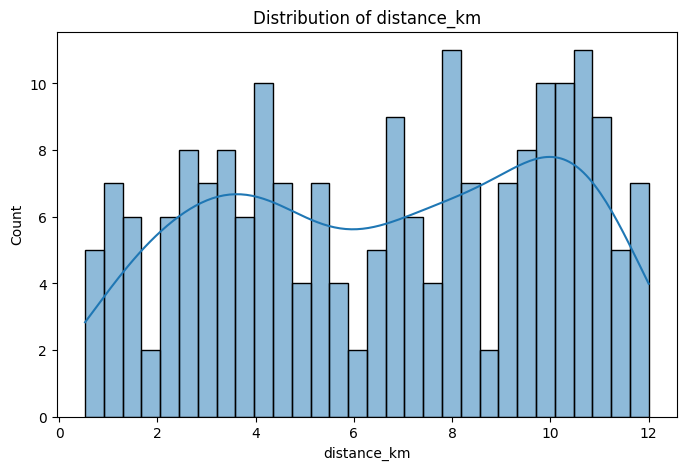

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



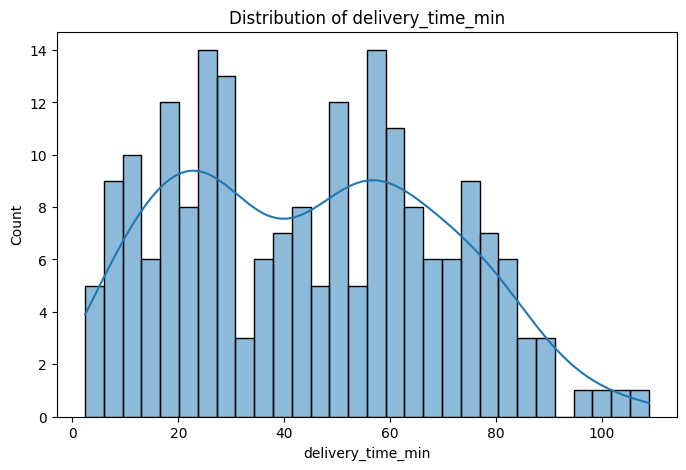

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



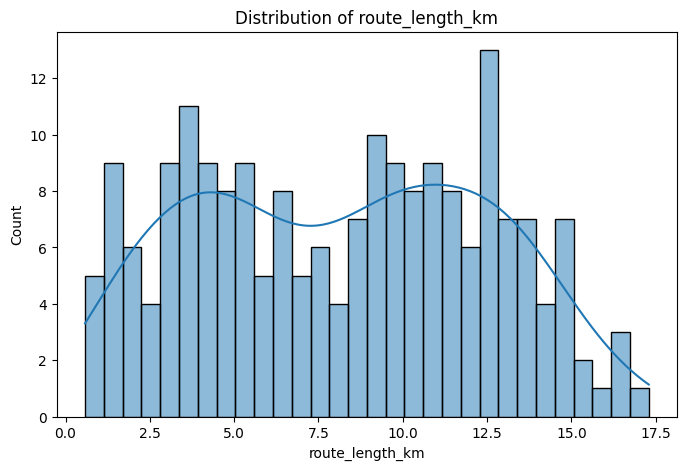

In [12]:
num_cols = ['distance_km','delivery_time_min','route_length_km']

for col in num_cols:
    plt.figure(figsize=(8,5))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


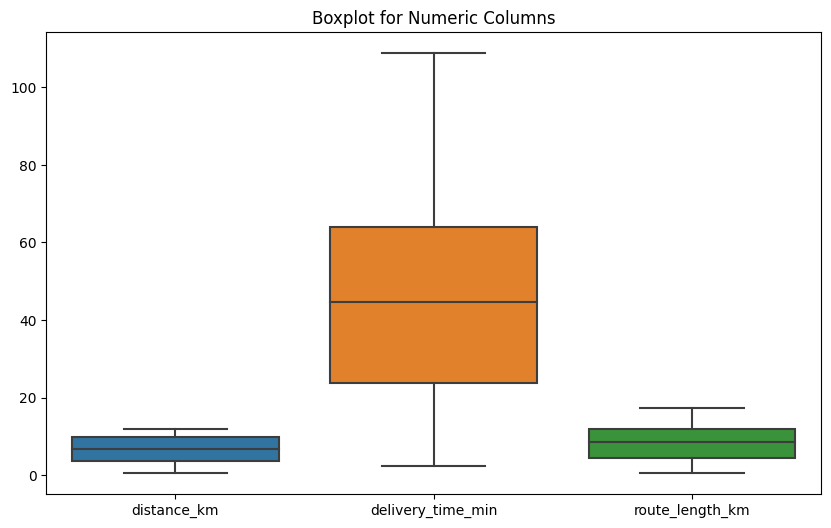

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[num_cols])
plt.title("Boxplot for Numeric Columns")
plt.show()


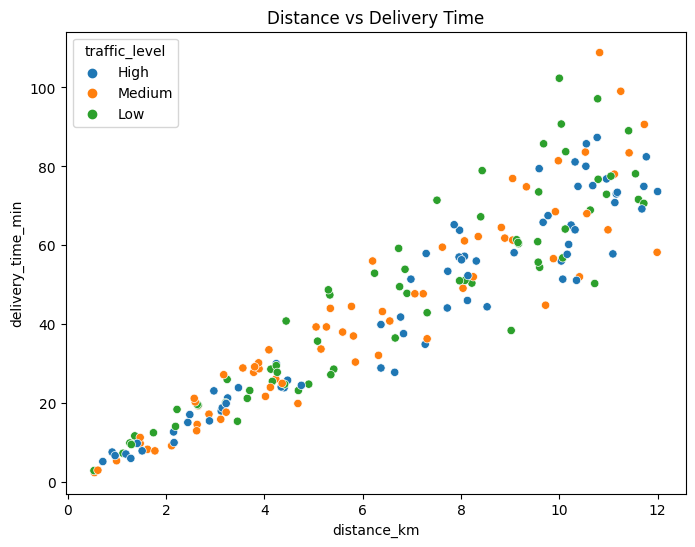

In [14]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='distance_km', y='delivery_time_min', hue='traffic_level')
plt.title("Distance vs Delivery Time")
plt.show()


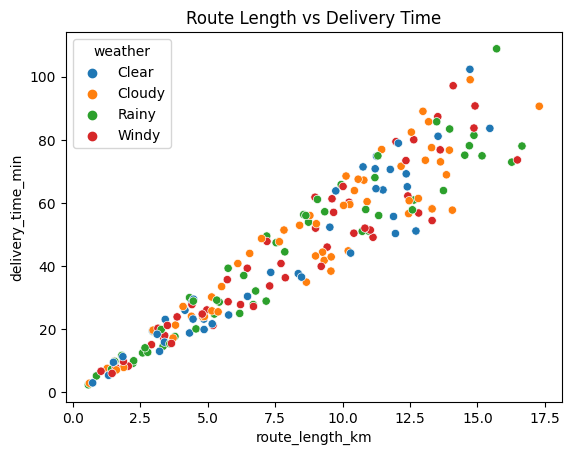

In [15]:
sns.scatterplot(data=df, x='route_length_km', y='delivery_time_min', hue='weather')
plt.title("Route Length vs Delivery Time")
plt.show()


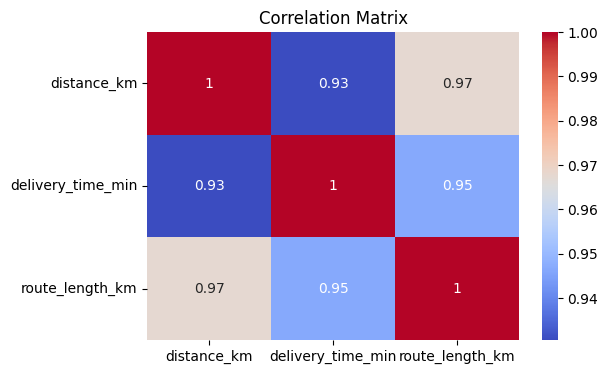

In [16]:
plt.figure(figsize=(6,4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


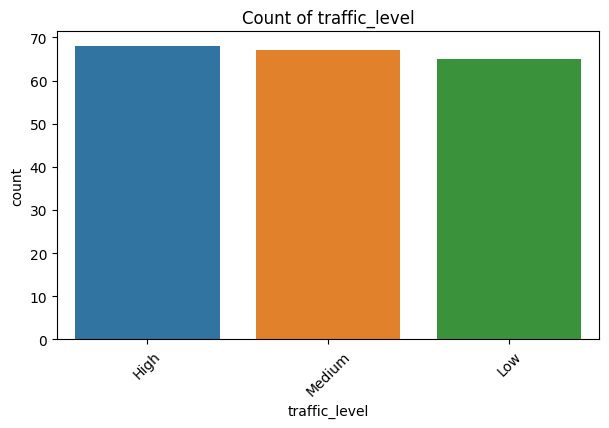

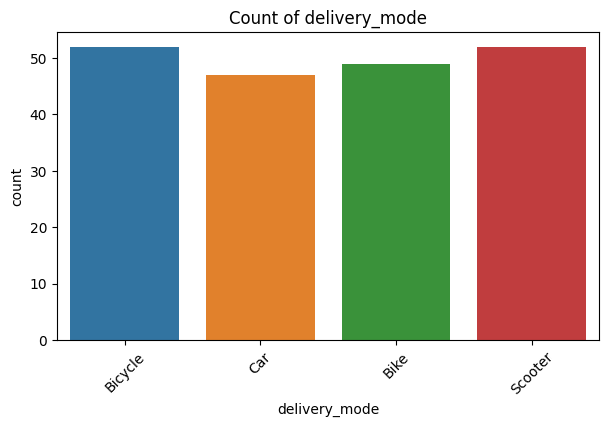

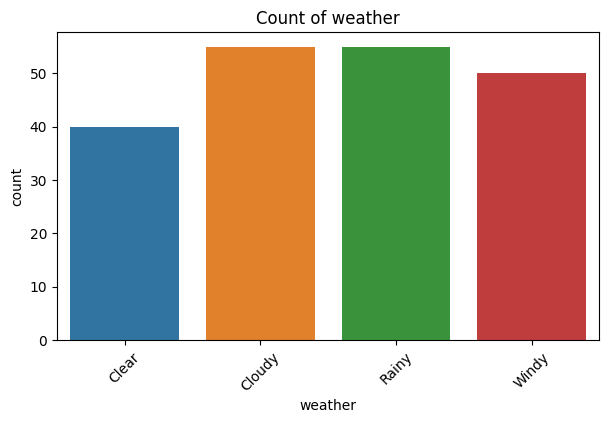

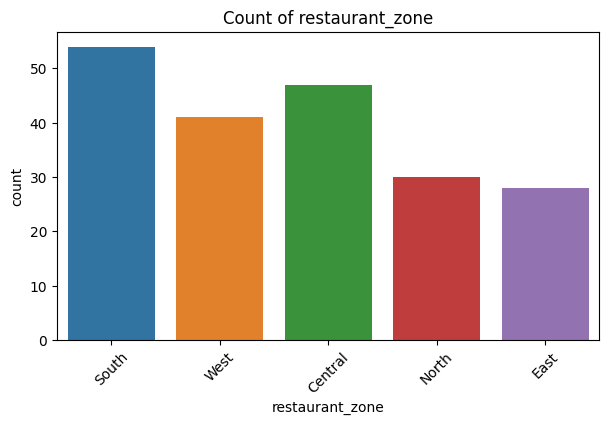

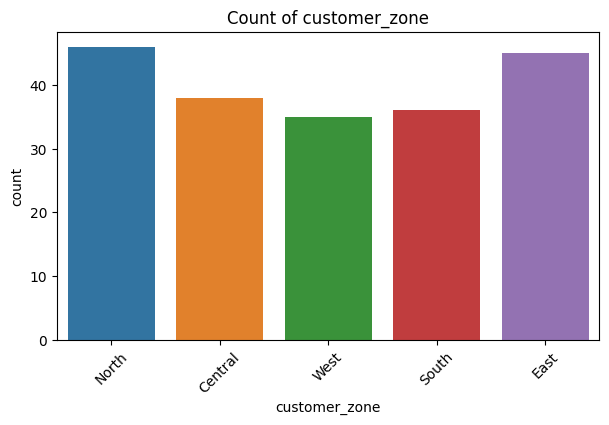

In [17]:
cat_cols = ['traffic_level','delivery_mode','weather','restaurant_zone','customer_zone']

for col in cat_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(data=df, x=col)
    plt.title(f"Count of {col}")
    plt.xticks(rotation=45)
    plt.show()


Fastest delivery mode: Car with an average time of: 41.48 minutes


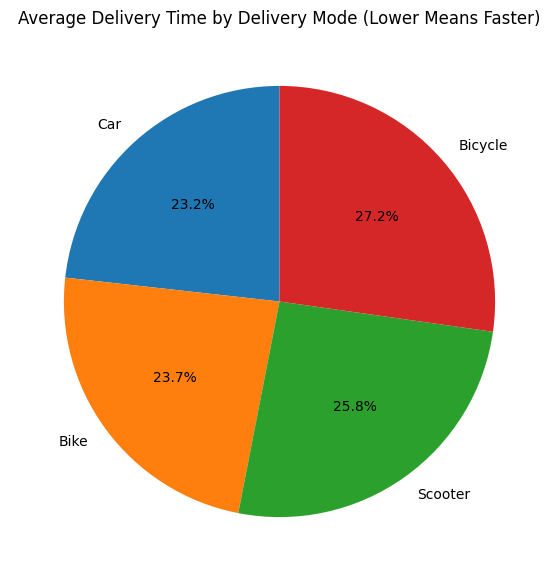

In [18]:



mode_speed = df.groupby("delivery_mode")["delivery_time_min"].mean().sort_values()

print("Fastest delivery mode:", mode_speed.index[0],
      "with an average time of:", round(mode_speed.iloc[0], 2), "minutes")

plt.figure(figsize=(7,7))
plt.pie(mode_speed, labels=mode_speed.index, autopct="%1.1f%%", startangle=90)
plt.title("Average Delivery Time by Delivery Mode (Lower Means Faster)")
plt.show()


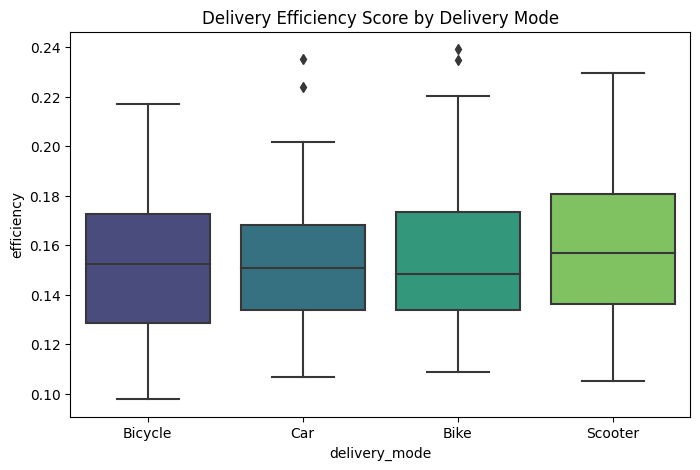

In [19]:
df["efficiency"] = df["distance_km"] / df["delivery_time_min"]

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="delivery_mode", y="efficiency", palette="viridis")
plt.title("Delivery Efficiency Score by Delivery Mode")
plt.show()


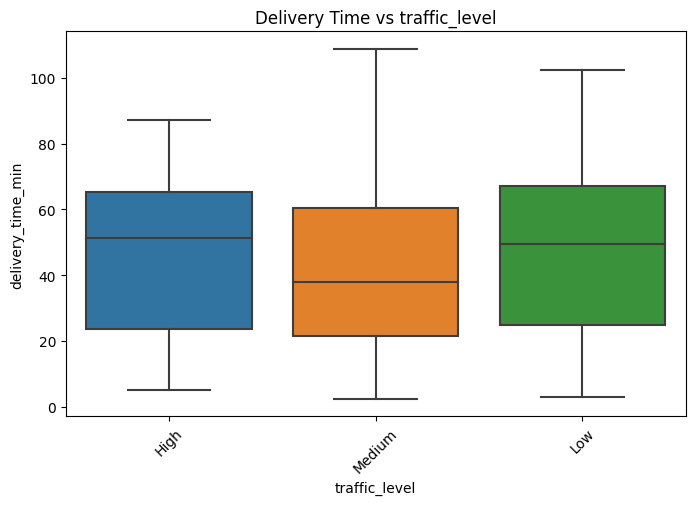

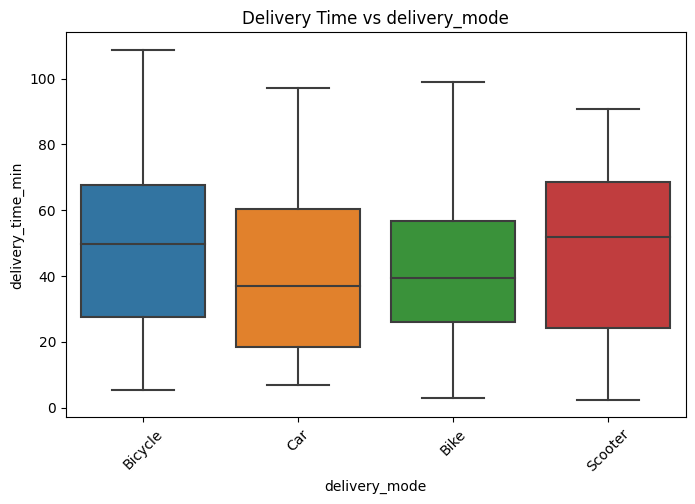

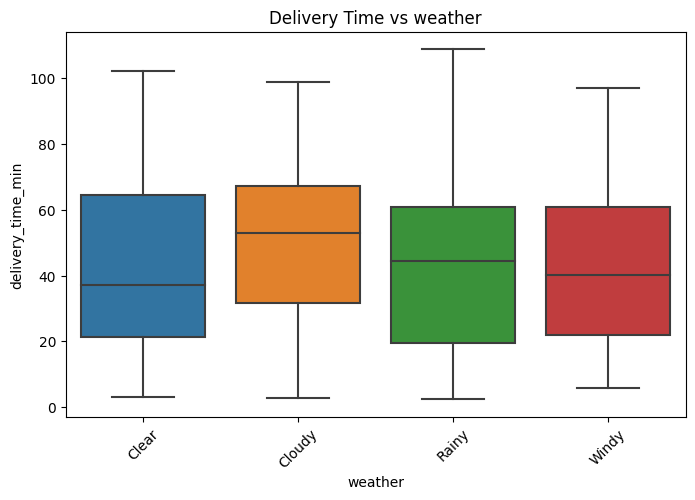

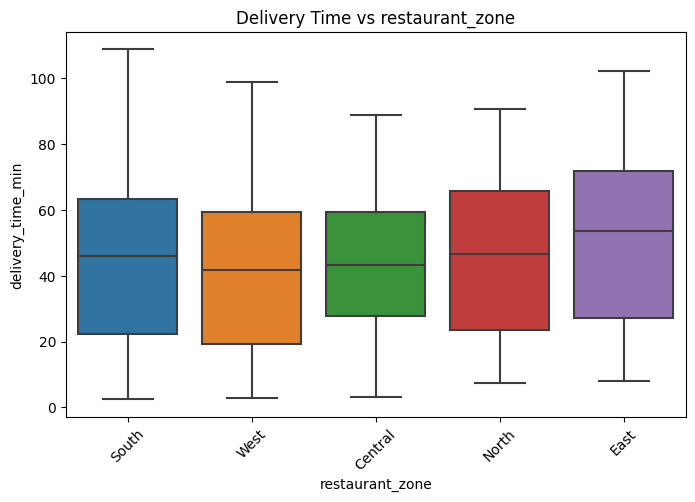

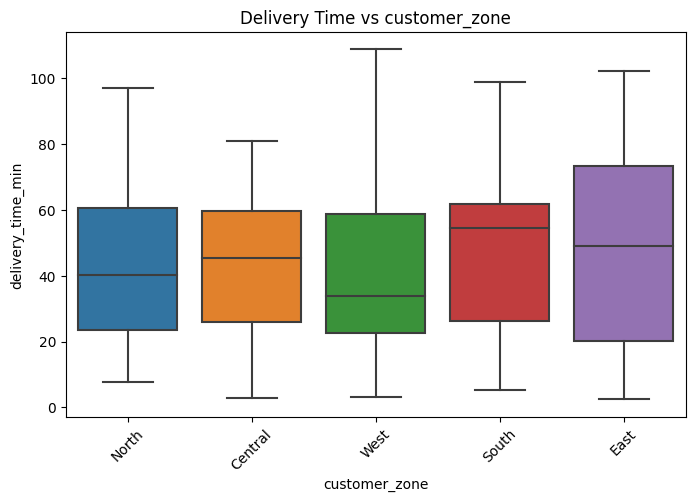

In [20]:
for col in cat_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df, x=col, y='delivery_time_min')
    plt.title(f"Delivery Time vs {col}")
    plt.xticks(rotation=45)
    plt.show()


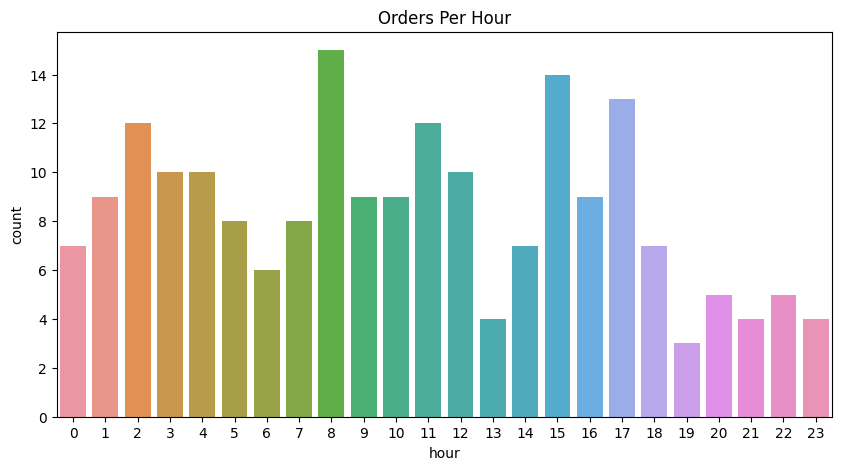

In [21]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='hour')
plt.title("Orders Per Hour")
plt.show()


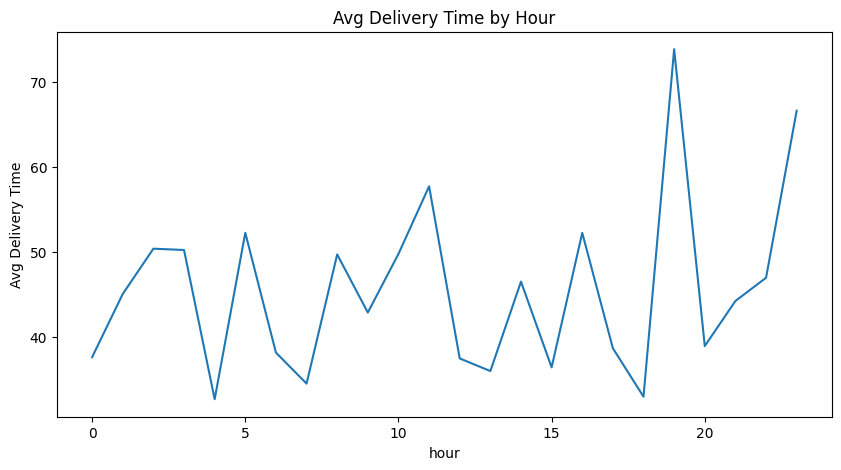

In [22]:
df.groupby('hour')['delivery_time_min'].mean().plot(kind='line', figsize=(10,5))
plt.title("Avg Delivery Time by Hour")
plt.ylabel("Avg Delivery Time")
plt.show()


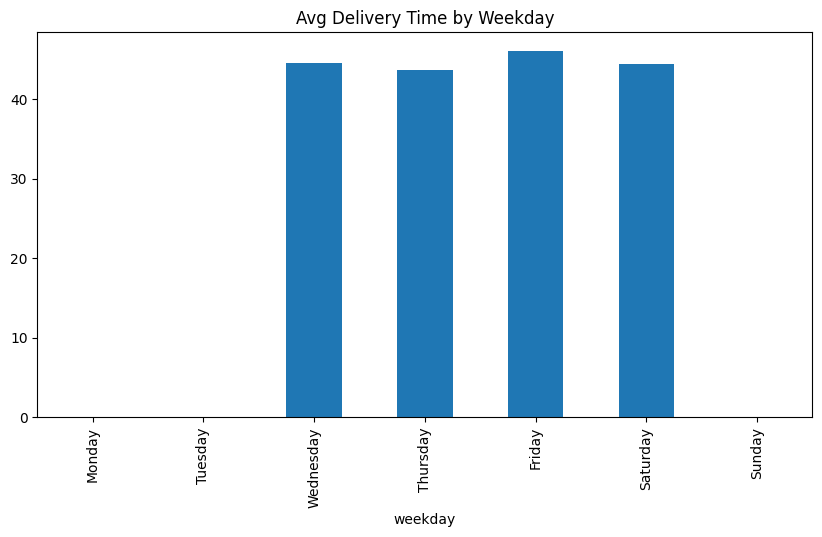

In [23]:
df.groupby('weekday')['delivery_time_min'].mean()\
  .reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])\
  .plot(kind='bar', figsize=(10,5))

plt.title("Avg Delivery Time by Weekday")
plt.show()


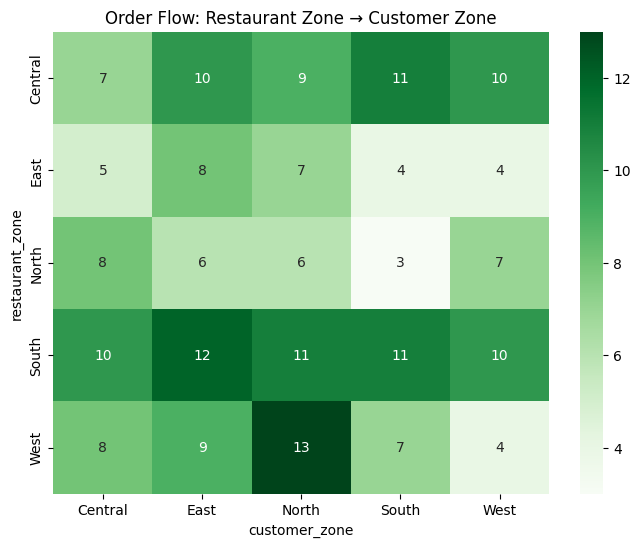

In [24]:
pivot = df.pivot_table(index='restaurant_zone', columns='customer_zone', values='order_id', aggfunc='count')

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, cmap="Greens")
plt.title("Order Flow: Restaurant Zone → Customer Zone")
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warn

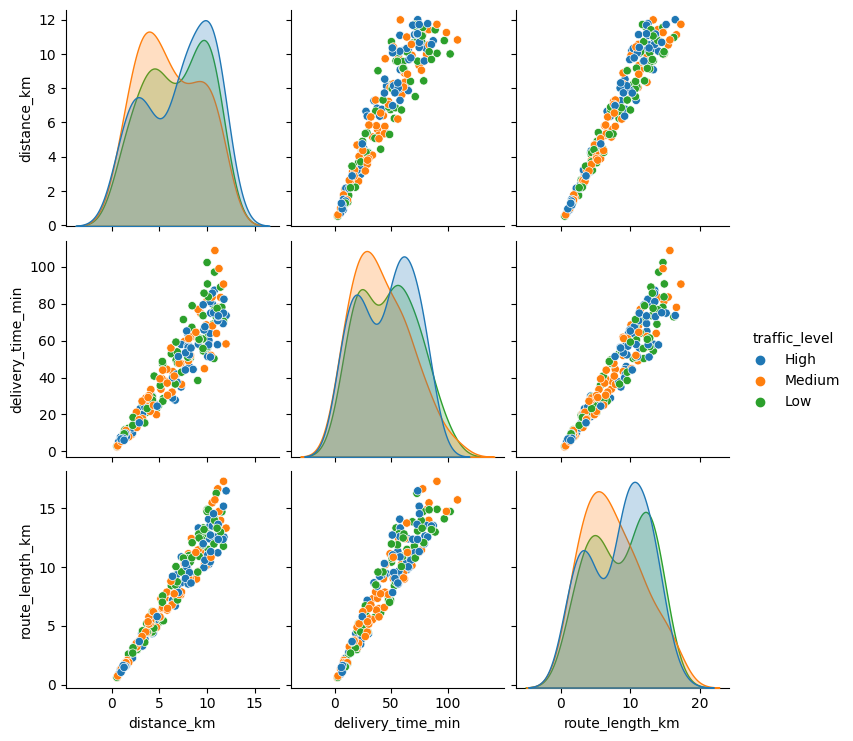

In [25]:
sns.pairplot(df[['distance_km','delivery_time_min','route_length_km','traffic_level']], hue='traffic_level')
plt.show()


The busiest delivery time

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning:

invalid value encountered in less



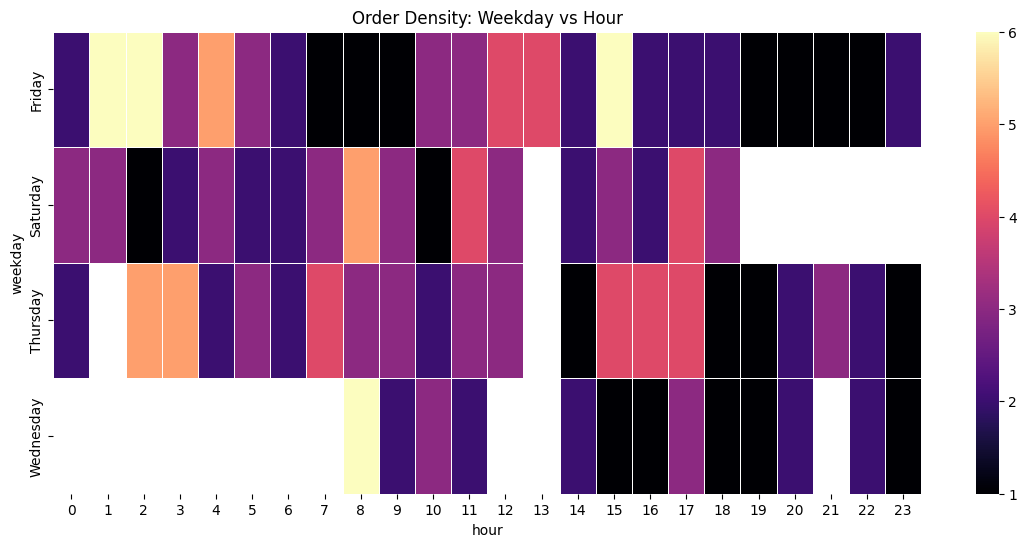

In [26]:
df["hour"] = df["order_time"].dt.hour
df["weekday"] = df["order_time"].dt.day_name()

pivot = df.pivot_table(index="weekday", columns="hour", values="order_id", aggfunc="count")

plt.figure(figsize=(14,6))
sns.heatmap(pivot, cmap="magma", linewidths=.5)
plt.title("Order Density: Weekday vs Hour")
plt.show()
